This is a jupyter notebook for Jonathan's experiments. I am so bad at coding lol...

In [15]:
import numpy as np

class lorenz1963:
    def __init__(self, rho, beta, sigma, numTimeSteps, initialCondition) -> None:
        self.rho = rho
        self.beta  = beta
        self.sigma = sigma
        self.numTimeSteps = numTimeSteps
        self.states = np.zeros((numTimeSteps, 3))
        self.states[0, :] = initialCondition
        self.tstep = 0
        
    
    def statesDot(self, currState) -> np.array:

        dx_dt = self.sigma*(currState[1] - currState[0])
        dy_dt = currState[0]*(self.rho - currState[2])
        dz_dt = currState[0]*currState[1] - self.beta*currState[2]

        states_dt = np.array([dx_dt, dy_dt, dz_dt])
        return states_dt
    def getCurrState(self) -> np.array:
        return self.states[self.tstep, :]

    def setState(self, nextState) -> None:
        self.tstep = self.tstep + 1
        self.states[self.tstep, :] = nextState
        





Testing Lorenz1963 chaotic class made above. This will also be used as the test case for the rk4 integrator.

In [16]:
testCase = lorenz1963(28, 8/3, 10, 1000, np.array([1, 2, 3]))
testCase.statesDot(np.array([1, 2, 3]))

array([10., 25., -6.])

In [17]:
def f2(currState, deltaT, f1) -> np.array:
    f2Output = f1(currState + deltaT/2*f1(currState))
    return f2Output

def f3(currState, deltaT, f1, f2) -> np.array:
    f3Output = f1(currState + deltaT/2*f2(currState, deltaT, f1))
    return f3Output

def f4(currState, deltaT, f1, f2, f3) -> np.array:
    f4Output = f1(currState + deltaT*f3(currState, deltaT, f1, f2))
    return f4Output


numTimeSteps = 10000
deltaT = 0.01
totalTime = numTimeSteps*deltaT


lorenzRK4 = lorenz1963(28, 8/3, 10, numTimeSteps+1, np.array([0, 1, 1.05]))

for ctime in np.linspace(0, totalTime, numTimeSteps):
    
    currState = lorenzRK4.getCurrState()
    f11 = lorenzRK4.statesDot(currState)
    f22 = f2(currState, deltaT, lorenzRK4.statesDot)
    f33 = f3(currState, deltaT, lorenzRK4.statesDot, f2)
    f44 = f4(currState, deltaT, lorenzRK4.statesDot, f2, f3)
    
    nextState = lorenzRK4.getCurrState() + deltaT/6*(f11 + 2*f22 + 2*f33 + f44)
    lorenzRK4.setState(nextState)

print(lorenzRK4.states)


[[ 0.          1.          1.05      ]
 [ 0.09558943  1.01307616  1.02285371]
 [ 0.1845426   1.05099774  0.99737098]
 ...
 [ 5.66252119  8.03478806 19.86517688]
 [ 5.91093525  8.5070849  19.81467004]
 [ 6.18176155  9.00208851 19.81555589]]


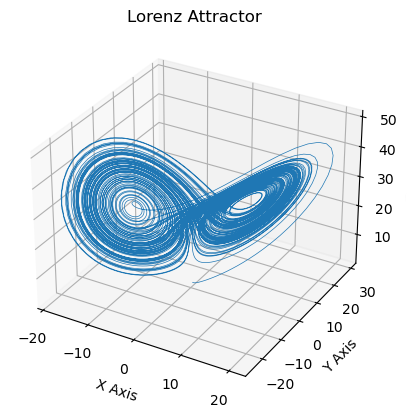

In [18]:
import matplotlib.pyplot as plt

# Plot
ax = plt.figure().add_subplot(projection='3d')

ax.plot(*lorenzRK4.states.T, lw=0.5)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor")

plt.show()